In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math



In [2]:
df = pd.read_csv("../data/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
def create_files_nulls_per_colmun(data_frame,table_name):
    nulls=data_frame.isna().sum()
    nulls.head()
    nulls.to_csv("dumps_from_notebooks/" + "null_count_" + table_name,index=False)
    porcentaje_of_nulls = (nulls * 100) / len(data_frame)
    porcentaje_of_nulls.head()
    porcentaje_of_nulls.to_csv("dumps_from_notebooks/null_porcentaje_" + table_name,index=False)



create_files_nulls_per_colmun(df,"aplication_train")

print(len(df))

307511


In [4]:

#now we will explore the hypothesis of train one model per type of contract. Starting for how viable is with the data available

print(df["NAME_CONTRACT_TYPE"].value_counts(normalize=True) * 100)
print(df.groupby("NAME_CONTRACT_TYPE")["TARGET"].mean() * 100)

#Considering the volume of the minoritary class (less than 10%) and their event ratio (5%) seems not ideal have to separate the models.



NAME_CONTRACT_TYPE
Cash loans         90.478715
Revolving loans     9.521285
Name: proportion, dtype: float64
NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64


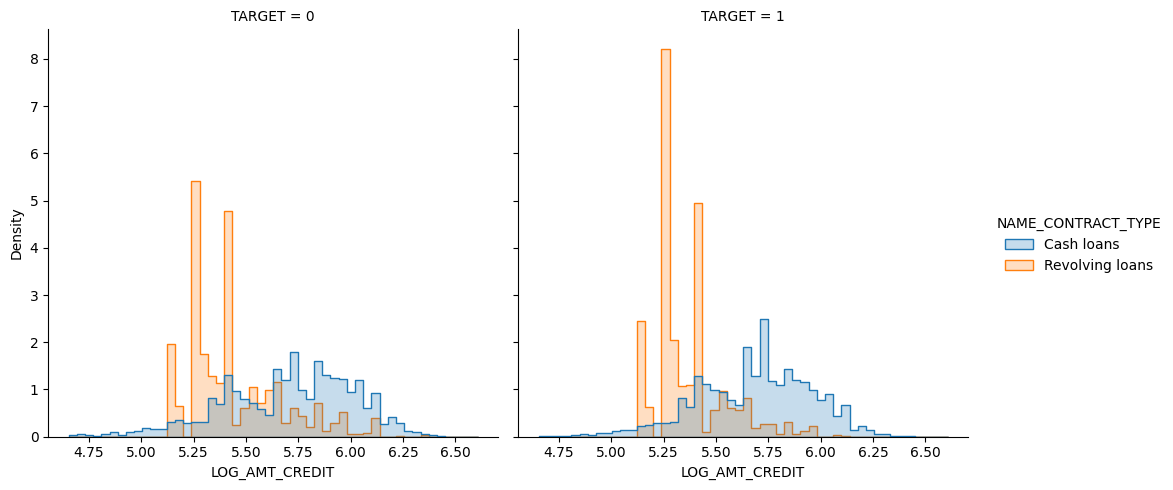

In [5]:
#here i want to check if the main variables that describes the loan change their distribution and trending between the type of contract,
#and also see how much change in the case of default. 

df["LOG_AMT_CREDIT"]= np.log10(df["AMT_CREDIT"])

g = sns.displot(
    data=df,
    x="LOG_AMT_CREDIT",
    hue="NAME_CONTRACT_TYPE",
    bins=50,
    element="step",
    stat="density",
    col="TARGET",
    common_norm=False
)

for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')

#default and the mont of the loan have negative correlation. In both type of contracts. That's a good proof about the similar behaivor between clases 
#and seems unnecesary split and train 2 diferent models.

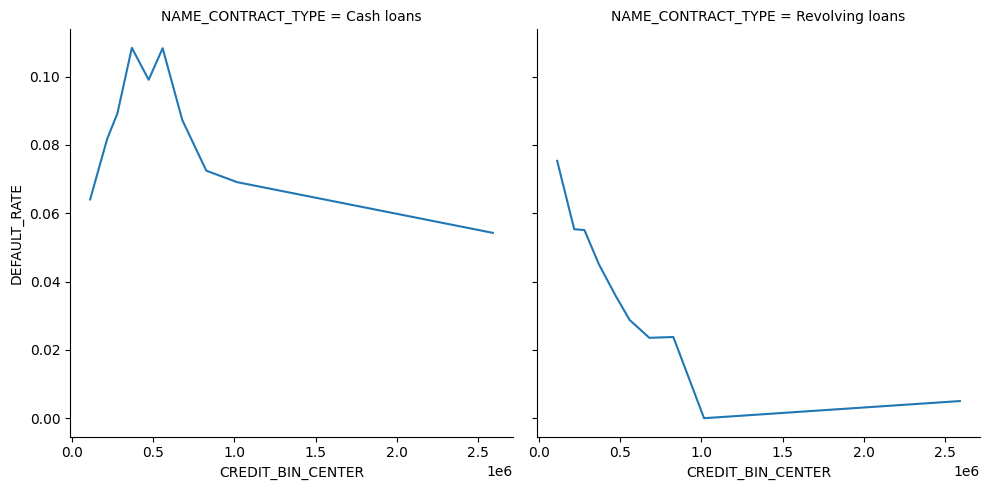

In [6]:
bins= np.arange(0,df["AMT_CREDIT"].max() + 100000, 100000)
df["BINED_AMT_CREDIT"]=  pd.qcut(df["AMT_CREDIT"],10)
df_groupBy_bins = df.groupby(["BINED_AMT_CREDIT","NAME_CONTRACT_TYPE"],observed=True)["TARGET"].agg(
    DEFAULT_RATE="mean",
    COUNT="size").reset_index()
df_groupBy_bins["CREDIT_BIN_CENTER"] = df_groupBy_bins["BINED_AMT_CREDIT"].apply(lambda x: x.mid)


gr=sns.relplot(data=df_groupBy_bins,x="CREDIT_BIN_CENTER",y="DEFAULT_RATE",kind="line",col="NAME_CONTRACT_TYPE")



<Axes: xlabel='CREDIT_BIN_CENTER', ylabel='DEFAULT_RATE'>

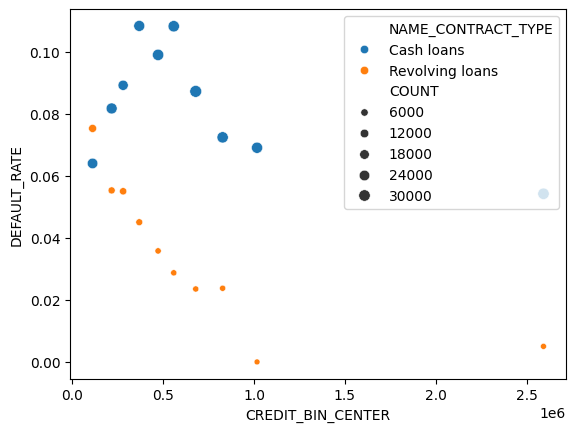

In [7]:
sns.scatterplot(
    data=df_groupBy_bins,
    x="CREDIT_BIN_CENTER",
    y="DEFAULT_RATE",
    hue="NAME_CONTRACT_TYPE",
    size="COUNT"
)


In [8]:
"""About the idea of creating 2 different models for each type of contract: 

The amount of data and events is something to consider.
revolving loans represent 9.5% of observations and have a default ratio of 5%.
Therefore, train separate models significantly reduce the amount of total data and default events.

the analysis of the deciles of amount of credit and their respective default rate show similar overall trends for both contracts types, but have noticiable diferences in some segments.
For linear models this would require some features to model the interaction but in case of using tree based models the feature CONTRACT_TYPE 
seems enough

In conclusion, this preliminary analisis show there is no strong evidence supporting the need for two separate models. Even so, this hypothesis
will be tested formally later comparing model performance.
"""

'About the idea of creating 2 different models for each type of contract: \n\nThe amount of data and events is something to consider.\nrevolving loans represent 9.5% of observations and have a default ratio of 5%.\nTherefore, train separate models significantly reduce the amount of total data and default events.\n\nthe analysis of the deciles of amount of credit and their respective default rate show similar overall trends for both contracts types, but have noticiable diferences in some segments.\nFor linear models this would require some features to model the interaction but in case of using tree based models the feature CONTRACT_TYPE \nseems enough\n\nIn conclusion, this preliminary analisis show there is no strong evidence supporting the need for two separate models. Even so, this hypothesis\nwill be tested formally later comparing model performance.\n'

In [9]:
bureau_df=pd.read_csv("../data/bureau.csv")
bureau_df.head()


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [10]:
create_files_nulls_per_colmun(bureau_df,"bureau")


In [11]:
bureau_df["CREDIT_DAY_OVERDUE"].min()
bureau_df["CREDIT_DAY_OVERDUE"].max()

2792